<a href="https://colab.research.google.com/github/jbolivar1975/MIAD_ML_NLP_2025/blob/main/Semana%202/S2TC1_RandomForests_Boosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de modelos Bagging, Random Forest y XGBoost

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de Bagging, Random Forest y XGBoost. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este taller se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [5]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [6]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 1 - Árbol de decisión manual

En la celda 1 creen un árbol de decisión **manualmente**  que considere los set de entrenamiento y test definidos anteriormente y presenten el RMSE y MAE del modelo en el set de test.

In [5]:
# Celda 1

import numpy as np
import pandas as pd

# ... (código para cargar datos y preprocesar) ...

def mse(y):
    """Calcula el Mean Squared Error."""
    if y.shape[0] == 0:
        return 0
    else:
        return np.mean((y - y.mean())**2)

def mae(y, y_pred):
    """Calcula el Mean Absolute Error."""
    return np.mean(np.abs(y - y_pred))

def mse_impurity(X_col, y, split):
    """Calcula la impureza basada en MSE."""
    filter_l = X_col < split
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]

    mse_y = mse(y)
    mse_l = mse(y_l)
    mse_r = mse(y_r)

    mse_impurity_ = mse_y - (n_l / (n_l + n_r) * mse_l + n_r / (n_l + n_r) * mse_r)

    return mse_impurity_

def best_split(X, y, num_pct=10):
    """Encuentra la mejor división para un nodo."""
    features = range(X.shape[1])
    best_split = [0, 0, 0]  # j, split, gain

    for j in features:
        splits = np.percentile(X.iloc[:, j], np.arange(0, 100, 100.0 / (num_pct+1)).tolist())
        splits = np.unique(splits)[1:]

        for split in splits:
            gain = mse_impurity(X.iloc[:, j], y, split)
            if gain > best_split[2]:
                best_split = [j, split, gain]

    return best_split

def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None, num_pct=10):
    """Construye el árbol de decisión recursivamente."""
    if X.shape[0] == 1:
        tree = dict(y_pred=y.iloc[:1].values[0], level=level, split=-1, n_samples=1, gain=0)
        return tree

    j, split, gain = best_split(X, y, num_pct)

    y_pred = y.mean()  # Predecir la media

    tree = dict(y_pred=y_pred, level=level, split=-1, n_samples=X.shape[0], gain=gain)

    if gain < min_gain:
        return tree
    if max_depth is not None:
        if level >= max_depth:
            return tree

    filter_l = X.iloc[:, j] < split
    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]
    tree['split'] = [j, split]

    tree['sl'] = tree_grow(X_l, y_l, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)
    tree['sr'] = tree_grow(X_r, y_r, level + 1, min_gain=min_gain, max_depth=max_depth, num_pct=num_pct)

    return tree

def tree_predict(X, tree, proba=False):
    """Realiza predicciones usando el árbol."""
    predicted = np.ones(X.shape[0])

    if tree['split'] == -1:
        predicted = predicted * tree['y_pred']
    else:
        j, split = tree['split']
        filter_l = (X.iloc[:, j] < split)
        X_l = X.loc[filter_l]
        X_r = X.loc[~filter_l]

        if X_l.shape[0] == 0:
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)
        elif X_r.shape[0] == 0:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
        else:
            predicted[filter_l] = tree_predict(X_l, tree['sl'], proba)
            predicted[~filter_l] = tree_predict(X_r, tree['sr'], proba)

    return predicted

# ... (código para crear y evaluar el árbol) ...

# Ejemplo de uso:
tree = tree_grow(X, y, level=0, min_gain=0.001, max_depth=3, num_pct=10)
y_pred = tree_predict(X, tree)

# Calcular MSE y MAE
mse_value = mse(y - y_pred)  # Calcular MSE de los residuos
mae_value = mae(y, y_pred)

print("MSE:", mse_value)
print("MAE:", mae_value)


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

### Punto 2 - Bagging manual

En la celda 2 creen un modelo bagging **manualmente** con 10 árboles de regresión y comenten sobre el desempeño del modelo.

In [7]:
train = pd.concat([y_train, X_train], axis=1)
test = pd.concat([y_test, X_test], axis=1)

train.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
318288,18495,2014,39988,False,False,False,False,False,True,False
333638,10891,2007,38904,False,False,False,False,True,False,False
234716,18994,2016,29607,False,False,False,False,False,True,False
208752,13691,2014,50756,False,False,False,False,False,True,False
348892,19999,2017,10506,False,False,False,False,False,True,False


In [9]:
# Celda 2

import numpy as np

# Se crea un arreglo de 1 a 20
np.random.seed(1)

# Impresión de arreglo y muestreo aleatorio
nums = np.arange(1, 21)
print('Arreglo:', nums)
print('Muestreo aleatorio: ', np.random.choice(a=nums, size=20, replace=True))

# Creación de 10 muestras de bootstrap
np.random.seed(123)

n_samples = train.shape[0]
n_B = 10

samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(1, n_B +1 )]
samples

# Visualización muestra boostrap #1 para entremiento
train.iloc[samples[0], :]

# Construcción un árbol de decisión para cada muestra boostrap

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

# Definición del modelo usando DecisionTreeRegressor de sklearn
treereg = DecisionTreeRegressor(max_depth=None, random_state=123)

# DataFrame para guardar las predicciones de cada árbol
y_pred_bagg = pd.DataFrame(index=test.index, columns=[list(range(n_B))])

# Entrenamiento de un árbol sobre cada muestra boostrap y predicción sobre los datos de test
for i, sample in enumerate(samples):
    X_train = train.iloc[sample, 1:]
    y_train = train.iloc[sample, 0]
    treereg.fit(X_train, y_train)
    y_pred_bagg.iloc[:,i] = treereg.predict(X_test)

y_pred_bagg

# Desempeño de cada árbol
for i in range(n_B):
    print('Árbol ', i, 'tiene un error: ', np.sqrt(mean_squared_error(y_pred_bagg.iloc[:,i], y_test)))

# Predicciones promedio para cada obserbación del set de test
y_pred_bagg.mean(axis=1)

# Error al promediar las predicciones de todos los árboles
np.sqrt(mean_squared_error(y_test, y_pred_bagg.mean(axis=1)))

Arreglo: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Muestreo aleatorio:  [ 6 12 13  9 10 12  6 16  1 17  2 13  8 14  7 19  6 19 12 11]
Árbol  0 tiene un error:  2141.613353645869
Árbol  1 tiene un error:  2136.3519863123465
Árbol  2 tiene un error:  2122.718759132052
Árbol  3 tiene un error:  2087.278992468617
Árbol  4 tiene un error:  2168.518742842026
Árbol  5 tiene un error:  2113.8811455834793
Árbol  6 tiene un error:  2127.933470769012
Árbol  7 tiene un error:  2184.414847251443
Árbol  8 tiene un error:  2138.1071697514985
Árbol  9 tiene un error:  2132.097520859104


np.float64(1796.4355868399332)

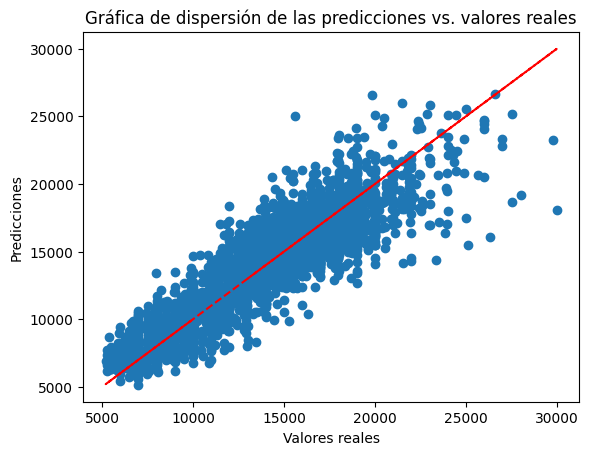

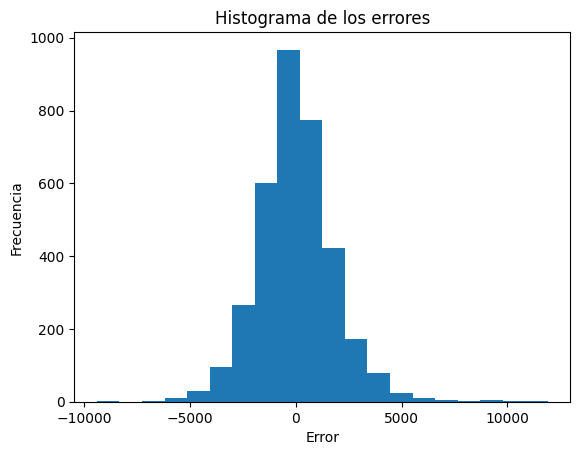

In [10]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_bagg.mean(axis=1))  # y_pred es el DataFrame con las predicciones de cada árbol
plt.plot(y_test, y_test, color='red', linestyle='--')  # Línea diagonal para referencia
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Gráfica de dispersión de las predicciones Bagging manual vs. valores reales')
plt.show()

errores = y_test - y_pred_bagg.mean(axis=1)
plt.hist(errores, bins=20)
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.title('Histograma de los errores - Bagging manual')
plt.show()


### Punto 3 - Bagging con librería

En la celda 3, con la librería sklearn, entrenen un modelo bagging con 10 árboles de regresión y el parámetro `max_features` igual a `log(n_features)` y comenten sobre el desempeño del modelo.

In [11]:
# Celda 3

# Uso de BaggingRegressor de la libreria (sklearn) donde se usa el modelo DecisionTreeRegressor como estimador
from sklearn.ensemble import BaggingRegressor
bagreg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=10, max_features= int(np.log(X_train.shape[1])),
                          bootstrap=True, oob_score=True, random_state=1)

# Entrenemiento del modelo con set de entrenamiento y predicción en el set de test
bagreg.fit(X_train, y_train)
y_pred_bagg_lib = bagreg.predict(X_test)
y_pred_bagg_lib

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_bagg_lib))

np.float64(2698.896838119253)

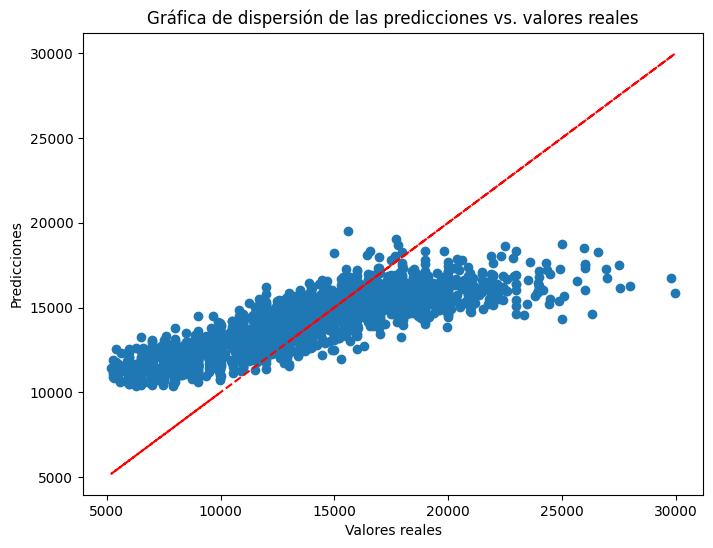

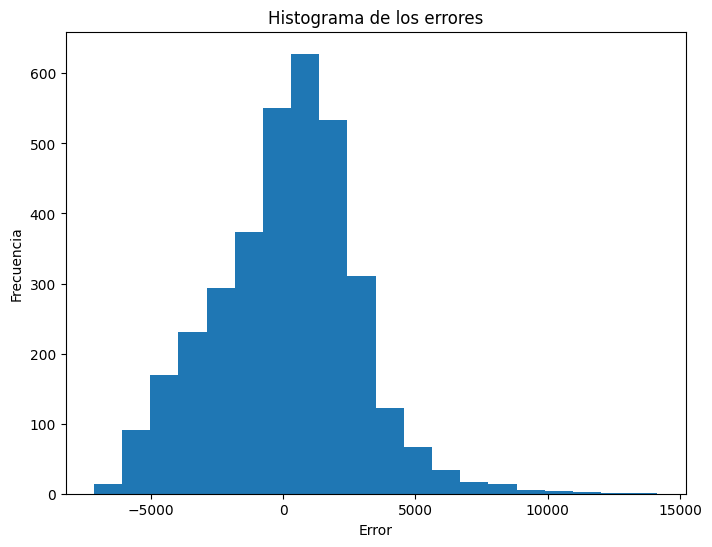

In [12]:
import matplotlib.pyplot as plt

# Gráfica de dispersión
plt.figure(figsize=(8, 6))  # Ajusta el tamaño de la figura si lo deseas
plt.scatter(y_test, y_pred_bagg_lib)  # y_pred_bagg_lib ya contiene las predicciones
plt.plot(y_test, y_test, color='red', linestyle='--')  # Línea diagonal
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Gráfica de dispersión de las predicciones Bagging con librería vs. valores reales')
plt.show()

# Histograma de los errores
plt.figure(figsize=(8, 6))  # Ajusta el tamaño de la figura si lo deseas
errores = y_test - y_pred_bagg_lib  # Calcula los errores sin mean(axis=1)
plt.hist(errores, bins=20)
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.title('Histograma de los errores - Bagging con librería')
plt.show()

### Punto 4 - Random forest con librería

En la celda 4, usando la librería sklearn entrenen un modelo de Randon Forest para regresión  y comenten sobre el desempeño del modelo.

In [18]:
# Celda 4

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import pandas as pd

# Definición de modelo Random Forest para un problema de regresión
clf = RandomForestRegressor()
clf

# Entrenar el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)  # Agrega esta línea para entrenar el modelo

# Obtener las predicciones del modelo en el conjunto de prueba
y_pred_rf = clf.predict(X_test)

# Calcular el RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Imprimir el RMSE
print(f"RMSE del modelo RandomForest: {rmse_rf}")

#Impresión de desempeño del modelo usando la función cross_val_score  (más detalles en https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html)
pd.Series(cross_val_score(clf, X, y, cv=10)).describe()


RMSE del modelo RandomForest: 1832.810640151933


,0
count,10.000000
mean,0.801324
std,0.010586
min,0.781896
25%,0.796552
50%,0.802819
75%,0.805022
max,0.815837


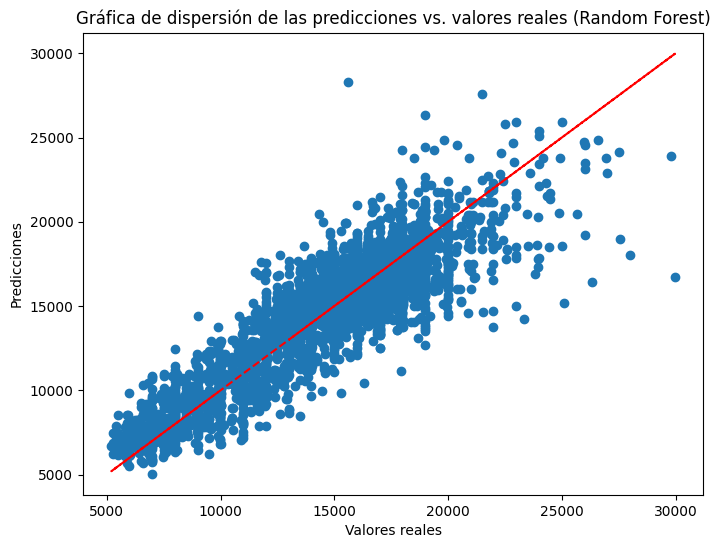

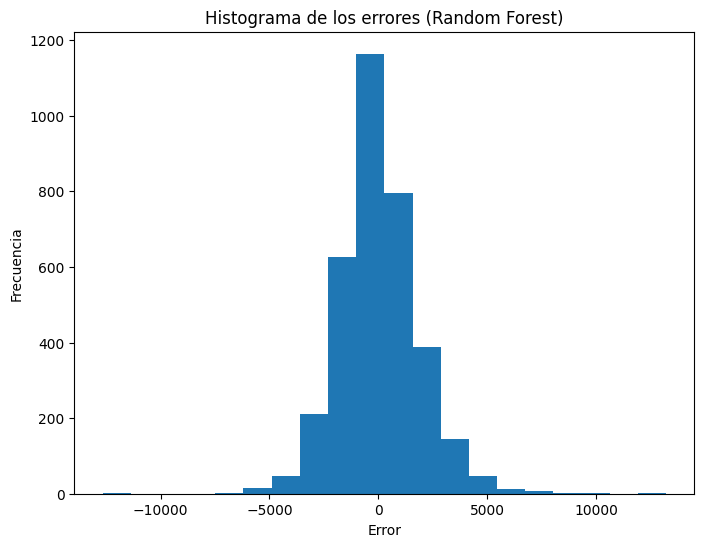

In [17]:
import matplotlib.pyplot as plt

# Gráfica de dispersión para Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf)  # Reemplaza y_pred_bagg_lib con y_pred_rf
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Gráfica de dispersión de las predicciones (Random Forest) vs. valores reales')
plt.show()

# Histograma de los errores para Random Forest
plt.figure(figsize=(8, 6))
errores_rf = y_test - y_pred_rf  # Reemplaza y_pred_bagg_lib con y_pred_rf
plt.hist(errores_rf, bins=20)
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.title('Histograma de los errores (Random Forest)')
plt.show()

### Punto 5 - Calibración de parámetros Random forest

En la celda 5, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

Text(0, 0.5, 'neg_mean_absolute_error')

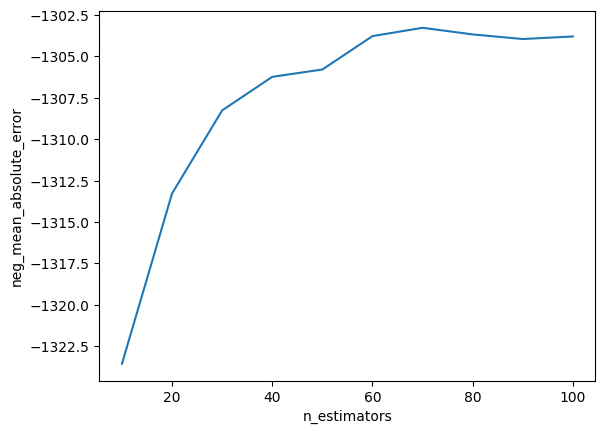

In [39]:
# Celda 5

# n_estimators es la cantidad de árboles a contruir dentro del bosque aleatorio.

# Creación de lista de valores para iterar sobre diferentes valores de n_estimators
estimator_range = range(10, 110, 10)

# Definición de lista para almacenar la métrica promedio para cada valor de n_estimators
metrica_scores = []

# Uso de un 5-fold cross-validation para cada valor de n_estimators
for estimator in estimator_range:
    clf = RandomForestRegressor(n_estimators=estimator, random_state=1, n_jobs=-1)
    metrica_scores.append(cross_val_score(clf, X, y, cv=5, scoring='neg_mean_absolute_error').mean())

# Gráfica del desempeño del modelo vs la cantidad de n_estimators
plt.plot(estimator_range, metrica_scores)
plt.xlabel('n_estimators')
plt.ylabel('neg_mean_absolute_error')

Text(0, 0.5, 'neg_mean_absolute_error')

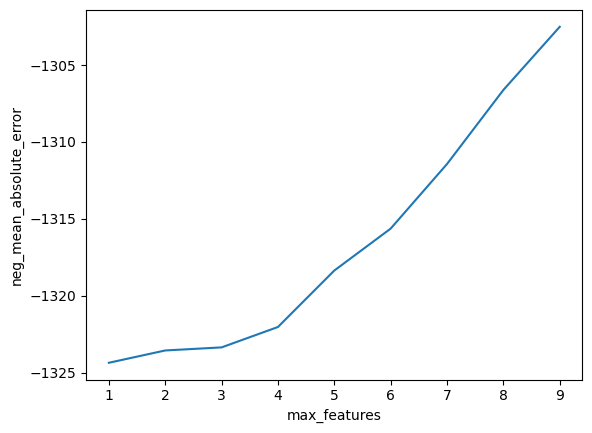

In [40]:

# max_features es el número de variables que se deben considerar en cada árbol.

# Creación de lista de valores para iterar sobre diferentes valores de max_features
feature_range = range(1, len(X.columns)+1)

# Definición de lista para almacenar la métrica promedio para cada valor de max_features
metrica_scores = []

# Uso de un 5-fold cross-validation para cada valor de max_features
for feature in feature_range:
    clf = RandomForestRegressor(n_estimators=100, max_features=feature, random_state=1, n_jobs=-1)
    metrica_scores.append(cross_val_score(clf, X, y, cv=5, scoring='neg_mean_absolute_error').mean())

# Gráfica del desempeño del modelo vs la cantidad de max_features
plt.plot(feature_range, metrica_scores)
plt.xlabel('max_features')
plt.ylabel('neg_mean_absolute_error')

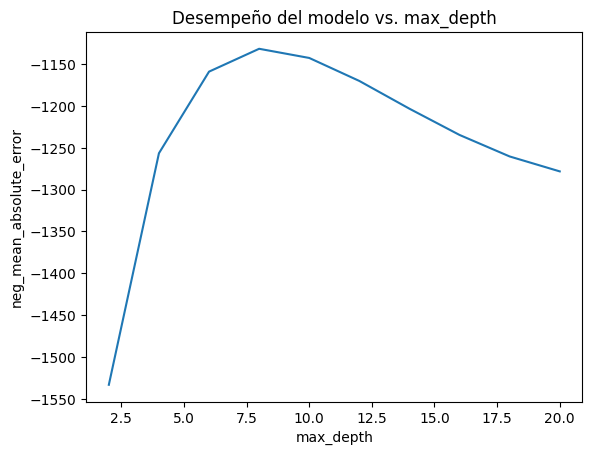

In [38]:
# parámetros max_depth

import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# Define el rango de valores para max_depth
depth_range = range(2, 21, 2)

# Lista para almacenar las puntuaciones de precisión
metrica_scores = []

# Itera sobre los valores de max_depth
for depth in depth_range:
    # Crea un modelo RandomForestRegressor con el max_depth actual
    clf = RandomForestRegressor(n_estimators=100, max_depth=depth, random_state=1, n_jobs=-1)

    # Calcula la puntuación de precisión utilizando validación cruzada de 5 pliegues
    scores = cross_val_score(clf, X, y, cv=5, scoring='neg_mean_absolute_error')

    # Agrega la puntuación media a la lista
    metrica_scores.append(scores.mean())

# Grafica los resultados
plt.plot(depth_range, metrica_scores)
plt.xlabel('max_depth')
plt.ylabel('neg_mean_absolute_error')
plt.title('Desempeño del modelo vs. max_depth')
plt.show()

In [43]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score
import pandas as pd

# Definición de modelo Random Forest para un problema de regresión con los paramtreos optimos
clf = RandomForestRegressor()
clf

clf = RandomForestRegressor(n_estimators=70, max_features=9, max_depth=8, random_state=1, n_jobs=-1)

# Entrenar el modelo con los datos de entrenamiento
clf.fit(X_train, y_train)  # Agrega esta línea para entrenar el modelo

# Obtener las predicciones del modelo en el conjunto de prueba
y_pred_rf = clf.predict(X_test)

# Calcular el RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

# Calcular el R-cuadrado
r2_rf = r2_score(y_test, y_pred_rf)

# Imprimir el RMSE
print(f"RMSE del modelo RandomForest con optimización de parámetros: {rmse_rf}")
# Imprimir el R-cuadrado
print(f"R-cuadrado del modelo RandomForest: {r2_rf}")

RMSE del modelo RandomForest con optimización de parámetros: 1592.0004340373127
R-cuadrado del modelo RandomForest: 0.8343069282203603


### Punto 6 - XGBoost con librería

En la celda 6 implementen un modelo XGBoost de regresión con la librería sklearn y comenten sobre el desempeño del modelo.

In [31]:
# Celda 6

from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Define el modelo XGBRegressor
regressor = XGBRegressor()

# Entrena el modelo
regressor.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_xgb = regressor.predict(X_test)

# Calcula las métricas de evaluación
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)  # Calcula la raíz cuadrada del MSE para obtener el RMSE
r2 = r2_score(y_test, y_pred_xgb)

# Imprime las métricas
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R-cuadrado: {r2}")


MSE: 2733628.5
RMSE: 1653.368833624246
R-cuadrado: 0.8212864398956299


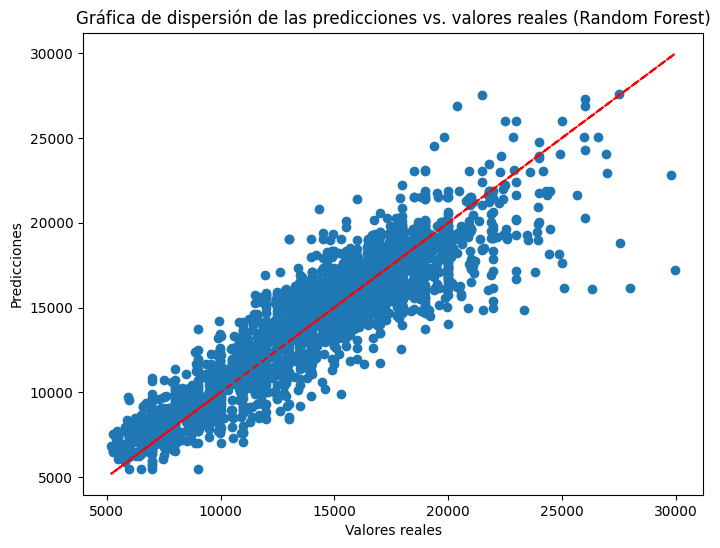

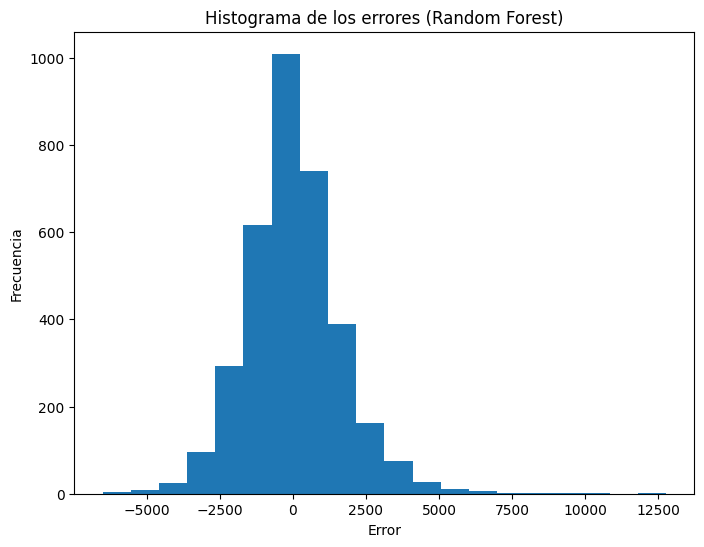

In [32]:
import matplotlib.pyplot as plt

# Gráfica de dispersión para Random Forest
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_xgb)  # Reemplaza y_pred_bagg_lib con y_pred_rf
plt.plot(y_test, y_test, color='red', linestyle='--')
plt.xlabel('Valores reales')
plt.ylabel('Predicciones')
plt.title('Gráfica de dispersión de las predicciones (XGBoost) vs. valores reales')
plt.show()

# Histograma de los errores para Random Forest
plt.figure(figsize=(8, 6))
errores_rf = y_test - y_pred_xgb  # Reemplaza y_pred_bagg_lib con y_pred_rf
plt.hist(errores_rf, bins=20)
plt.xlabel('Error')
plt.ylabel('Frecuencia')
plt.title('Histograma de los errores (XGBoost)')
plt.show()

### Punto 7 - Calibración de parámetros XGBoost

En la celda 7 calibren los parámetros learning rate, gamma y colsample_bytree del modelo XGBoost para regresión, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [37]:
# Celda 7

from xgboost import XGBRegressor

# Define el modelo XGBRegressor con parámetros específicos
regressor = XGBRegressor(
#learning_rate: Controla la velocidad de aprendizaje del modelo. Un valor más bajo puede llevar a un mejor rendimiento, pero requiere más tiempo de entrenamiento.
    learning_rate=0.2,
#gamma: Controla la complejidad del modelo. Un valor más alto puede prevenir el sobreajuste, pero puede reducir el rendimiento en conjuntos de datos pequeños.
    gamma=0,
#colsample_bytree: Controla la fracción de features (columnas) que se utilizan para construir cada árbol. Un valor más bajo puede prevenir el sobreajuste, pero puede reducir el rendimiento en conjuntos de datos con features importantes.
    colsample_bytree=1
)

# Entrena el modelo
regressor.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred_xgb = regressor.predict(X_test)

# Calcula las métricas de evaluación
mse = mean_squared_error(y_test, y_pred_xgb)
rmse = np.sqrt(mse)  # Calcula la raíz cuadrada del MSE para obtener el RMSE
r2 = r2_score(y_test, y_pred_xgb)

# Imprime las métricas
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R-cuadrado: {r2}")

MSE: 2603082.0
RMSE: 1613.4069542431012
R-cuadrado: 0.8298210501670837


In [36]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# Define el modelo XGBRegressor
regressor = xgb.XGBRegressor()

# Define la cuadrícula de parámetros a explorar
param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'gamma': [0, 0.1, 0.2],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# Crea un objeto GridSearchCV
grid_search = GridSearchCV(
    estimator=regressor,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',  # O cualquier otra métrica de regresión
    cv=5,  # Número de pliegues en la validación cruzada
    n_jobs=-1  # Utiliza todos los núcleos del procesador
)

# Ajusta el GridSearchCV a los datos de entrenamiento
grid_search.fit(X_train, y_train)

# Imprime los mejores parámetros encontrados
print("Mejores parámetros:", grid_search.best_params_)

# Obtén el mejor modelo
best_model = grid_search.best_estimator_

Mejores parámetros: {'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2}


### Punto 8 - Comparación y análisis de resultados
En la celda 8 comparen los resultados obtenidos de los diferentes modelos (random forest y XGBoost) y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

In [ ]:
# Celda 8
